<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/3%20K-Nearest%20Neigbours%20Regression%20(for%20Slides).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

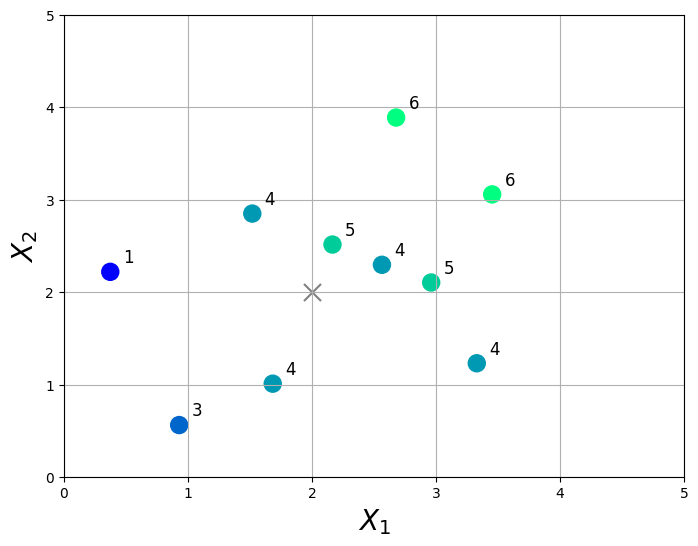

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Setting a random seed for reproducibility
np.random.seed(24)

# Generate 10 random data points centered around (2, 2)
data_points = np.array([[2, 2]]) + np.random.randn(10, 2)  # Adding normally distributed noise centered at 2
labels = np.round(1.75*data_points[:, 0] + np.random.normal(0, 1, 10))  # Regression labels as integers

# New point for prediction
new_point = np.array([2, 2])

# Create the plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
plt.scatter(data_points[:, 0], data_points[:, 1], c=labels, cmap='winter', s=150, marker='o')
plt.scatter(new_point[0], new_point[1], color='grey', s=150, marker='x')  # Highlight new point

for i in range(10) :
    ax.text(data_points[i, 0]+0.1, data_points[i,1]+0.1, int(labels[i]), fontsize=12)

# Adding labels, title, and legend
#plt.colorbar(label='Target value')
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([0, 5, 0, 5])

# Show grid
plt.grid(True)

# Display the plot
plt.show()



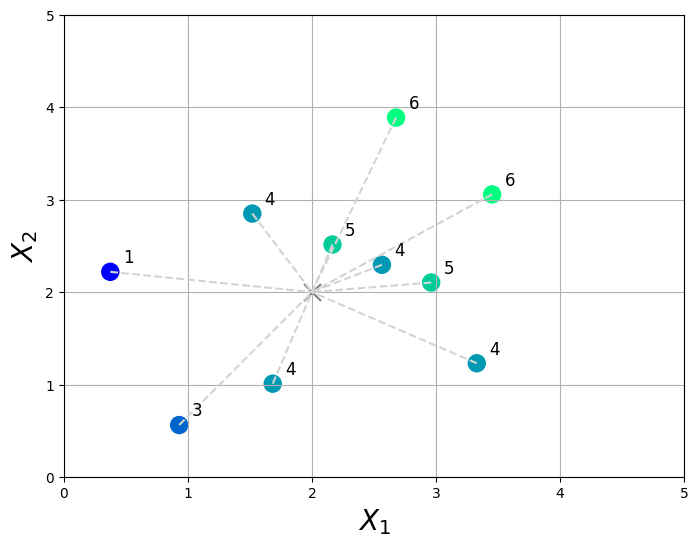

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Setting a random seed for reproducibility
np.random.seed(24)

# Generate 10 random data points centered around (2, 2)
data_points = np.array([[2, 2]]) + np.random.randn(10, 2)  # Adding normally distributed noise centered at 2
labels = np.round(1.75*data_points[:, 0] + np.random.normal(0, 1, 10))  # Regression labels as integers

# New point for prediction
new_point = np.array([2, 2])

# Create the plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
for i in range(10) :
    x = np.vstack((data_points[i,:], new_point))
    plt.plot(x[:,0], x[:,1], '--', c='lightgray')

plt.scatter(data_points[:, 0], data_points[:, 1], c=labels, cmap='winter', s=150, marker='o')
plt.scatter(new_point[0], new_point[1], color='grey', s=150, marker='x')  # Highlight new point

for i in range(10) :
    ax.text(data_points[i, 0]+0.1, data_points[i,1]+0.1, int(labels[i]), fontsize=12)

# Adding labels, title, and legend
#plt.colorbar(label='Target value')
plt.xlabel('$X_1$', fontsize=20)
plt.ylabel('$X_2$', fontsize=20)
plt.axis([0, 5, 0, 5])

# Show grid
plt.grid(True)

# Display the plot
plt.show()



In [ ]:
from sklearn.metrics import pairwise_distances
from collections import Counter

def kNN_Classify(new_point, data_points, labels, k, distance_metric='euclidean'):
    # Step 1: Calculate distances using pairwise_distances
    distances = pairwise_distances(data_points, new_point, metric=distance_metric).ravel()

    # Step 2 & 3: Sort distances and select k nearest neighbors
    k_nearest_neighbors_indices = np.argsort(distances)[:k]
    k_nearest_labels = labels[k_nearest_neighbors_indices]

    # Step 4: Perform majority vote
    most_common = Counter(k_nearest_labels).most_common(1)

    # Step 5: Determine the predicted class
    predicted_class = most_common[0][0]

    return predicted_class

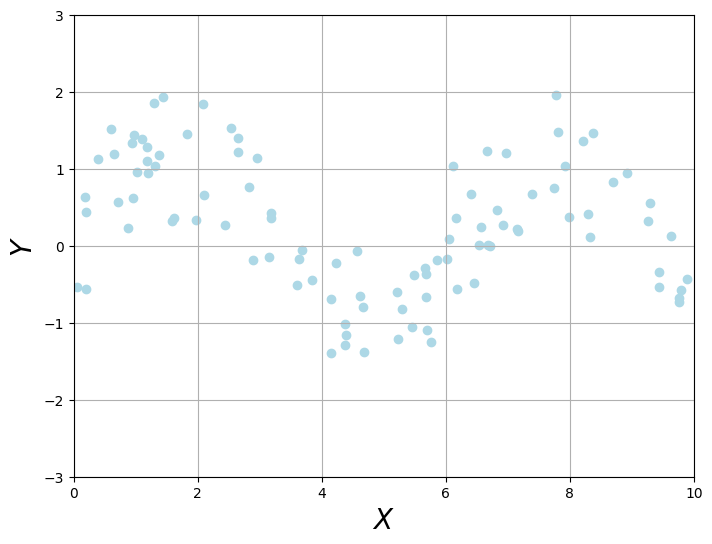

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set the random seed for reproducibility
np.random.seed(0)

# Generate synthetic data for KNN regression
X = np.sort(np.random.rand(100) * 10).reshape((-1,1))  # 100 data points from 0 to 6
noise = np.random.normal(0, 0.5, X.shape[0])  # Noise with standard deviation of 0.1
y = np.sin(X[:,0]) + noise  # y is a noisy sine function

# Plot the data points
plt.figure(figsize=(8, 6))
plt.scatter(X[:,0], y, color='lightblue')
plt.xlabel('$X$', fontsize=20)
plt.ylabel('$Y$', fontsize=20)
plt.axis([0, 10, -3, 3])
plt.grid()
plt.show()


X.shape

In [ ]:
from sklearn.model_selection import train_test_split

# First, split the data into train (60%) and temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

# Then split the temp data into validation (50% of 40% => 20% of total) and test (remaining 50% of 40% => 20% of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Checking the proportion of each set
print("Training Set Size:", len(X_train))
print("Validation Set Size:", len(X_val))
print("Test Set Size:", len(X_test))


Training Set Size: 60
Validation Set Size: 20
Test Set Size: 20


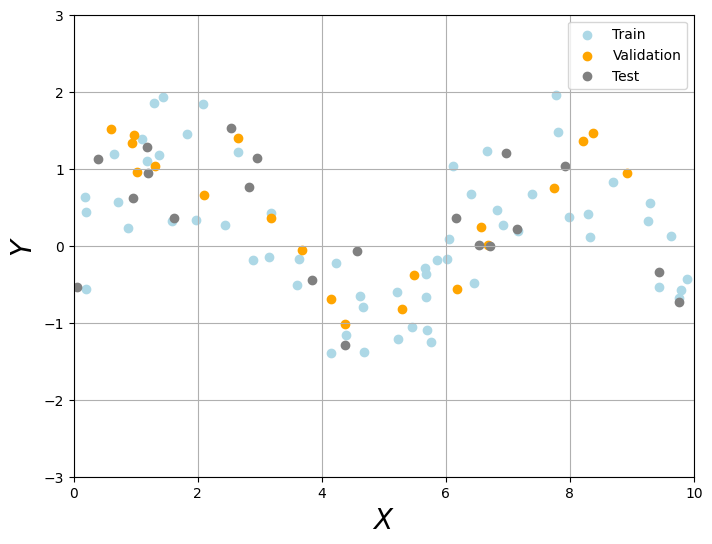

In [ ]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train, y_train, color='lightblue', label='Train', marker='o')
plt.scatter(X_val, y_val, color='orange', label='Validation', marker='o')
plt.scatter(X_test, y_test, color='grey', label='Test', marker='o')

# Adding labels and legend
plt.xlabel('$X$', fontsize=20)
plt.ylabel('$Y$', fontsize=20)
plt.axis([0, 10, -3, 3])
plt.legend()

# Show grid
plt.grid(True)

# Display the plot
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Define k and the distance metric
k = 5
distance_metric = 'euclidean'

# Create an instance of KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=k, metric=distance_metric)

# Fit the model on the training data
knn.fit(X_train, y_train)

# Predict the target values on the validation set
predictions = knn.predict(X_val)

# Calculate the mean squared error of the predictions
mse = mean_squared_error(y_val, predictions)
print("Mean Squared Error of the k-NN regressor on the validation set: {:.2f}".format(mse))


Mean Squared Error of the k-NN regressor on the validation set: 0.29


In [ ]:
xx = np.arange(0, 10, 0.01).reshape((-1,1))

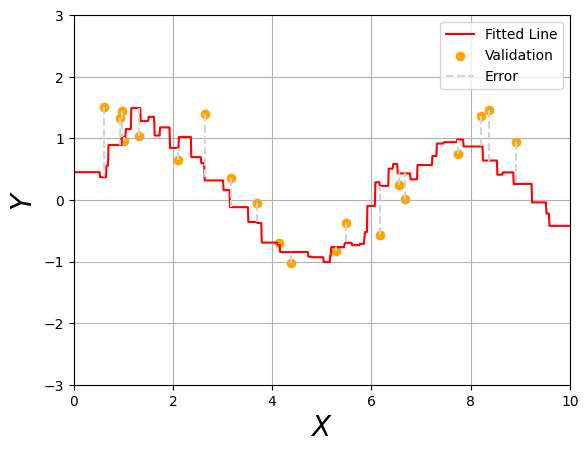

In [ ]:
yy = knn.predict(xx)

plt.plot(xx[:,0], yy, 'r-', label="Fitted Line")
plt.scatter(X_val[:,0], y_val, color="orange", marker="o", label="Validation")
for i in range(X_val.shape[0]) :
    xe = np.vstack((X_val[i, 0], X_val[i, 0]))
    ye = np.vstack((y_val[i].reshape(-1,1), knn.predict([X_val[i,:]]).reshape(-1,1)))
    plt.plot(xe, ye, '--', color="lightgray")
plt.plot(xe, ye, '--', color="lightgray", label="Error")
plt.axis([0, 10, -3, 3])
plt.xlabel("$X$", fontsize=20)
plt.ylabel("$Y$", fontsize=20)
plt.legend()
plt.grid()
plt.show()

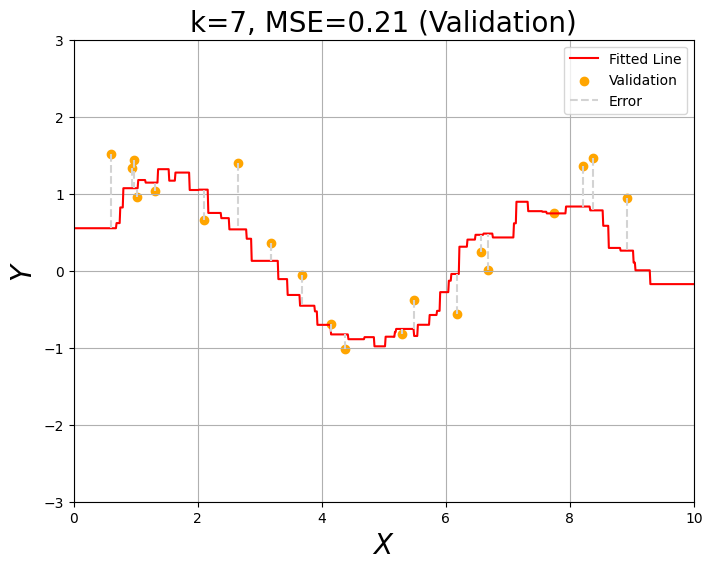

In [ ]:
k = 7
distance_metric = 'euclidean'

# Create an instance of KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=k, metric=distance_metric)

# Fit the model on the training data
knn.fit(X_train, y_train)

xx = np.arange(0, 10, 0.01).reshape((-1,1))
yy = knn.predict(xx)

plt.figure(figsize=(8, 6))
plt.plot(xx[:,0], yy, 'r-', label="Fitted Line")
plt.scatter(X_val[:,0], y_val, color="orange", marker="o", label="Validation")
for i in range(X_val.shape[0]) :
    xe = np.vstack((X_val[i, 0], X_val[i, 0]))
    ye = np.vstack((y_val[i].reshape(-1,1), knn.predict([X_val[i,:]]).reshape(-1,1)))
    plt.plot(xe, ye, '--', color="lightgray")
plt.plot(xe, ye, '--', color="lightgray", label="Error")
plt.axis([0, 10, -3, 3])
plt.xlabel("$X$", fontsize=20)
plt.ylabel("$Y$", fontsize=20)
plt.legend()
plt.grid()

mse = mean_squared_error(y_val, knn.predict(X_val))
plt.title("k=" + str(k) + ", MSE=" + str(np.round(mse,2)) + " (Validation)", fontsize=20)
plt.show()# Define k and the distance metric


In [ ]:
from sklearn.metrics import accuracy_score

# Define k and the distance metric
k = 5
distance_metric = 'euclidean'

# Call the kNN_Classify function to predict the validation set
predictions = kNN_Classify(X_val, X_train, y_train, k, distance_metric)

# Calculate the accuracy of the predictions
accuracy = accuracy_score(y_val, predictions)
print("Accuracy of the k-NN classifier on the validation set:", accuracy)

Accuracy of the k-NN classifier on the validation set: 0.85


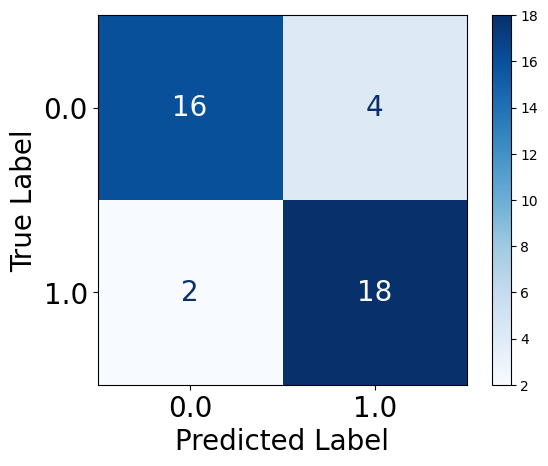

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fontsize = 20
ax = ConfusionMatrixDisplay.from_predictions(y_val, predictions, cmap=plt.cm.Blues)
#plt.plot()
for entries in ax.text_.ravel():
    entries.set_fontsize(fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xlabel("Predicted Label", fontsize=fontsize)
plt.ylabel("True Label", fontsize=fontsize)
plt.show()


In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
# Define your CustomKNNClassifier following scikit-learn conventions...

class CustomKNNClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric

    def fit(self, X, y):
        self.X_train_ = X
        self.y_train_ = y
        return self

    def predict(self, X):
        # Your custom predict logic here
        y_pred = []
        for x in X:
            # Calculate distances
            distances = pairwise_distances(self.X_train_, [x], metric=self.distance_metric).ravel()

            # Get indices of k nearest neighbors
            k_nearest_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = self.y_train_[k_nearest_indices]

            # Perform majority vote
            most_common = Counter(k_nearest_labels).most_common(1)
            predicted_class = most_common[0][0]
            y_pred.append(predicted_class)

        return np.array(y_pred)


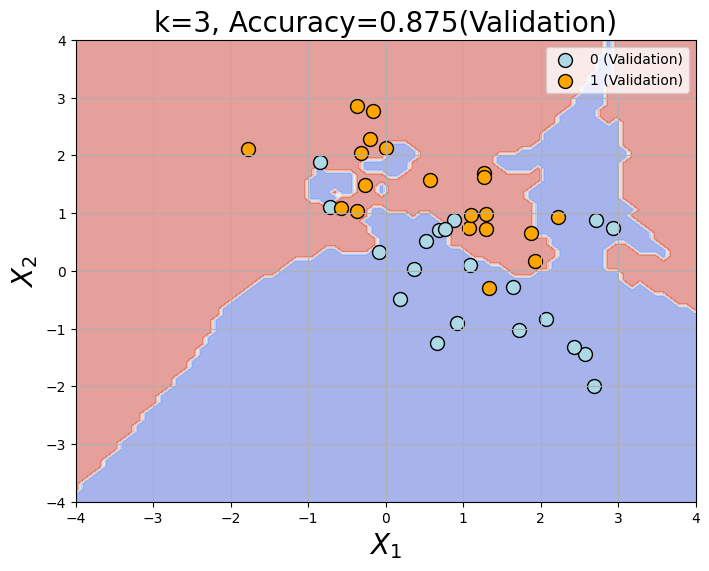

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay

k = 3
distance_metric = "euclidean"

xv, yv = np.meshgrid(np.linspace(-4,4,400), np.linspace(-4,4,400))

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    estimator=knn,
    X=np.vstack((xv.ravel(), yv.ravel())).T,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['0', '1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
#ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(X_val))))
ax.set_xlabel('$X_1$', fontsize=20)
ax.set_ylabel('$X_2$', fontsize=20)
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.axis([-4, 4, -4, 4])
plt.title("k=" + str(k) + ", Accuracy=" + str(accuracy_score(y_val, knn.predict(X_val))) + "(Validation)", fontsize=20)
plt.grid()
plt.show()

In [ ]:
xv, yv = np.meshgrid(np.linspace(-4,4,400), np.linspace(-4,4,400))
np.vstack((xv.ravel(), yv.ravel())).T

array([[-4.        , -4.        ],
       [-3.97994987, -4.        ],
       [-3.95989975, -4.        ],
       ...,
       [ 3.95989975,  4.        ],
       [ 3.97994987,  4.        ],
       [ 4.        ,  4.        ]])

In [ ]:
neighbours = np.arange(1,31)
validation_scores = []
train_scores = []
for k in neighbours :
    knn = KNeighborsRegressor(n_neighbors=k, metric=distance_metric)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)

    validation_scores.append(mean_squared_error(y_val, knn.predict(X_val)))
    train_scores.append(mean_squared_error(y_train, knn.predict(X_train)))

validation_scores = np.array(validation_scores)
train_scores = np.array(train_scores)

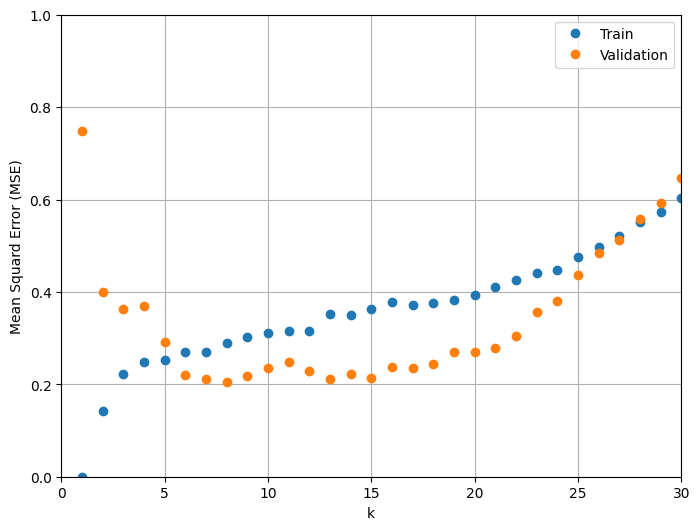

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(neighbours, train_scores, 'o', label="Train")
plt.plot(neighbours, validation_scores, 'o', label="Validation")
plt.xlabel('k')
plt.ylabel('Mean Squard Error (MSE)')
plt.axis([0, 30, 0.0, 1.0])
plt.grid()
plt.legend()
plt.show()

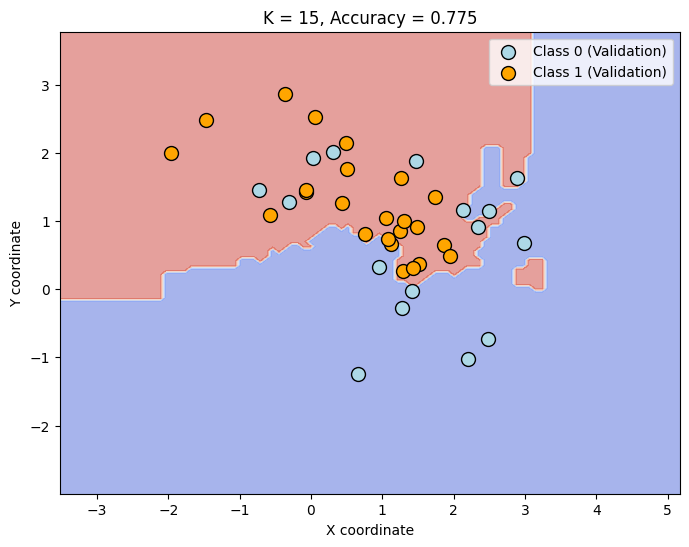

In [ ]:
k = 15
distance_metric = "manhattan"

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    knn,
    X_train,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['Class 0', 'Class 1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(X_val))))
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.show()

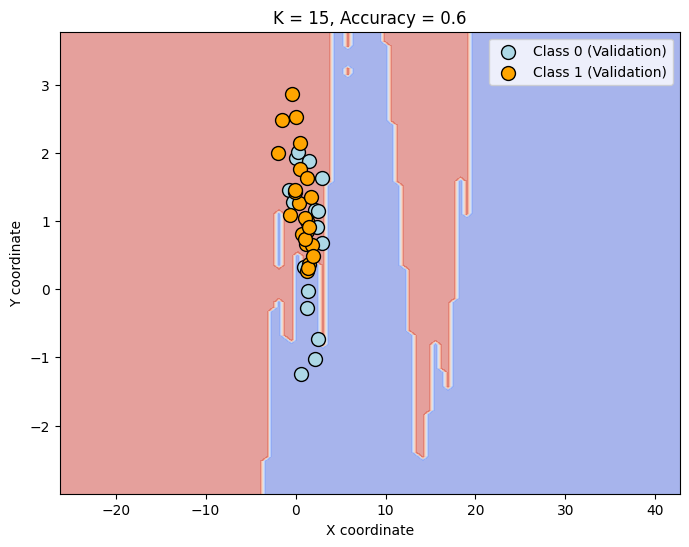

In [ ]:
k = 15
distance_metric = "euclidean"
scale = np.array([10, 1])

# Train the classifier
knn = CustomKNNClassifier(k=k, distance_metric=distance_metric)
knn.fit(scale*X_train, y_train)

# Plotting decision boundaries
fig, ax = plt.subplots(figsize=(8, 6))
db_display = DecisionBoundaryDisplay.from_estimator(
    knn,
    scale*X_train,
    response_method="predict",
    alpha=0.5,
    ax=ax,
    cmap='coolwarm'
)

# Scatter plot of the validation data with class labels
class_names = ['Class 0', 'Class 1']
colors = ['lightblue', 'orange']  # Define colors for different classes
for i, color in enumerate(colors):
    idx = np.where(y_val == i)
    ax.scatter(X_val[idx, 0], X_val[idx, 1], c=color, edgecolor='k', s=100, label=f'{class_names[i]} (Validation)')

# Adding labels, title and custom legend for validation data
ax.set_title('K = ' + str(k) +  ', Accuracy = ' + str(accuracy_score(y_val, knn.predict(scale*X_val))))
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.legend(loc='best')  # Position the legend to not overlap with data
plt.show()

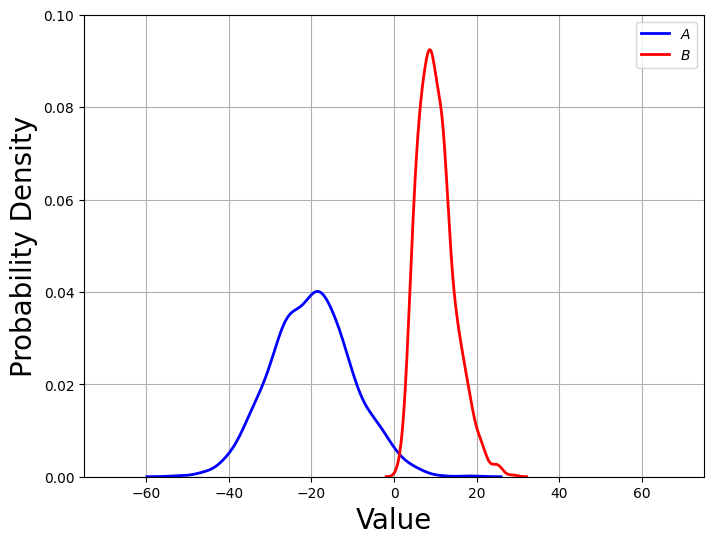

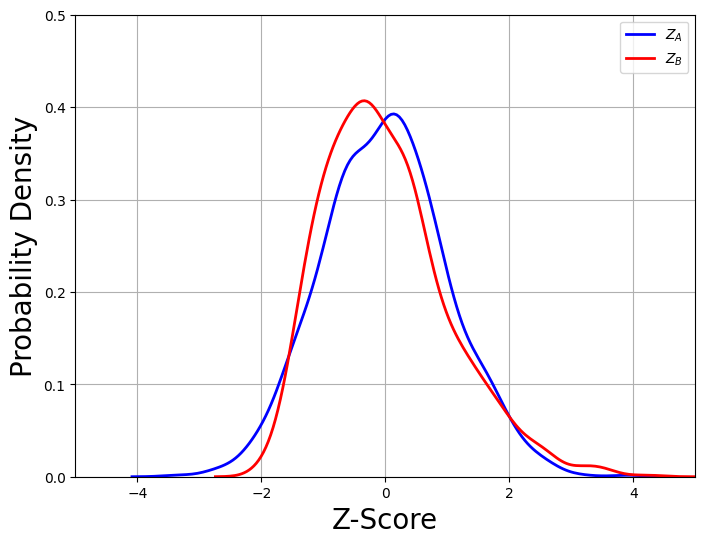

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Generate and standardize data
data_normal = np.random.normal(loc=-20, scale=10, size=1000)
data_gamma = np.random.gamma(shape=5, scale=2, size=1000)
z_normal = (data_normal - np.mean(data_normal)) / np.std(data_normal)
z_gamma = (data_gamma - np.mean(data_gamma)) / np.std(data_gamma)

# Plotting using seaborn for easier KDE
plt.figure(figsize=(8, 6))
sns.kdeplot(data_normal, label='$A$', color='blue', lw=2)
sns.kdeplot(data_gamma, label='$B$', color='red', lw=2)
plt.xlabel("Value", fontsize=20)
plt.ylabel("Probability Density", fontsize=20)
plt.axis([-75, 75, 0, 0.1])
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8, 6))
sns.kdeplot(z_normal, label='$Z_{A}$', color='blue', lw=2)
sns.kdeplot(z_gamma, label='$Z_{B}$', color='red', lw=2)
plt.xlabel("Z-Score", fontsize=20)
plt.ylabel("Probability Density", fontsize=20)
plt.axis([-5, 5, 0, 0.5])
plt.legend()
plt.grid()
plt.show()


In [ ]:
np.mean(data_normal), np.std(data_normal), np.mean(data_gamma), np.std(data_gamma)

(-19.806679441776744, 9.787262077473542, 10.16331996051392, 4.401450303905136)

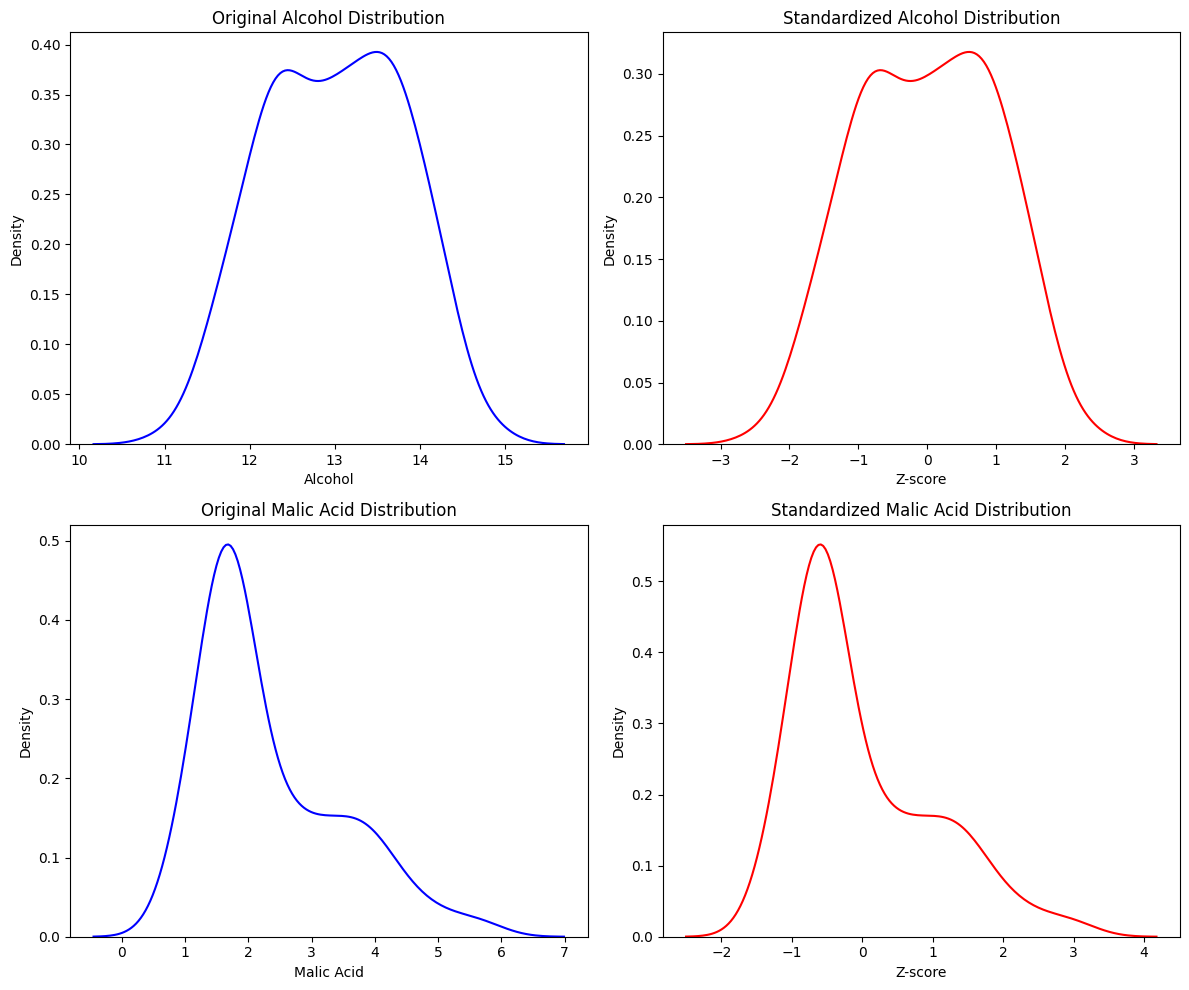

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Iris dataset
data = load_iris()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a standard scaler object
scaler = StandardScaler()

# Fit the scaler to the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set up GridSearchCV to find the optimal k for k-NN
param_grid = {'n_neighbors': list(range(1, 31))}

# Grid search on the original data
knn_gs_original = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_original.fit(X_train, y_train)
best_k_original = knn_gs_original.best_params_['n_neighbors']
best_score_original = knn_gs_original.best_score_

# Evaluate on test data
predictions_original = knn_gs_original.predict(X_test)
accuracy_original = accuracy_score(y_test, predictions_original)

# Grid search on the scaled data
knn_gs_scaled = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_scaled.fit(X_train_scaled, y_train)
best_k_scaled = knn_gs_scaled.best_params_['n_neighbors']
best_score_scaled = knn_gs_scaled.best_score_

# Evaluate on test data
predictions_scaled = knn_gs_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, predictions_scaled)

# Output the results
print(f"Optimal k on original data: {best_k_original}, Validation Score: {best_score_original:.2f}, Test Accuracy: {accuracy_original:.2f}")
print(f"Optimal k on scaled data: {best_k_scaled}, Validation Score: {best_score_scaled:.2f}, Test Accuracy: {accuracy_scaled:.2f}")


In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load the Wine dataset
data = load_wine()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a standard scaler object
scaler = StandardScaler()

# Fit the scaler to the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Set up GridSearchCV to find the optimal k for k-NN
param_grid = {'n_neighbors': list(range(1, 31))}

# Grid search on the original data
knn_gs_original = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_original.fit(X_train, y_train)
best_k_original = knn_gs_original.best_params_['n_neighbors']
best_score_original = knn_gs_original.best_score_

# Evaluate on test data
predictions_original = knn_gs_original.predict(X_test)
accuracy_original = accuracy_score(y_test, predictions_original)

# Grid search on the scaled data
knn_gs_scaled = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_gs_scaled.fit(X_train_scaled, y_train)
best_k_scaled = knn_gs_scaled.best_params_['n_neighbors']
best_score_scaled = knn_gs_scaled.best_score_

# Evaluate on test data
predictions_scaled = knn_gs_scaled.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, predictions_scaled)

# Output the results
print(f"Optimal k on original data: {best_k_original}, Validation Score: {best_score_original:.2f}, Test Accuracy: {accuracy_original:.2f}")
print(f"Optimal k on scaled data: {best_k_scaled}, Validation Score: {best_score_scaled:.2f}, Test Accuracy: {accuracy_scaled:.2f}")


Optimal k on original data: 17, Validation Score: 0.73, Test Accuracy: 0.78
Optimal k on scaled data: 13, Validation Score: 0.96, Test Accuracy: 0.97


In [ ]:
X_train.shape

(142, 13)

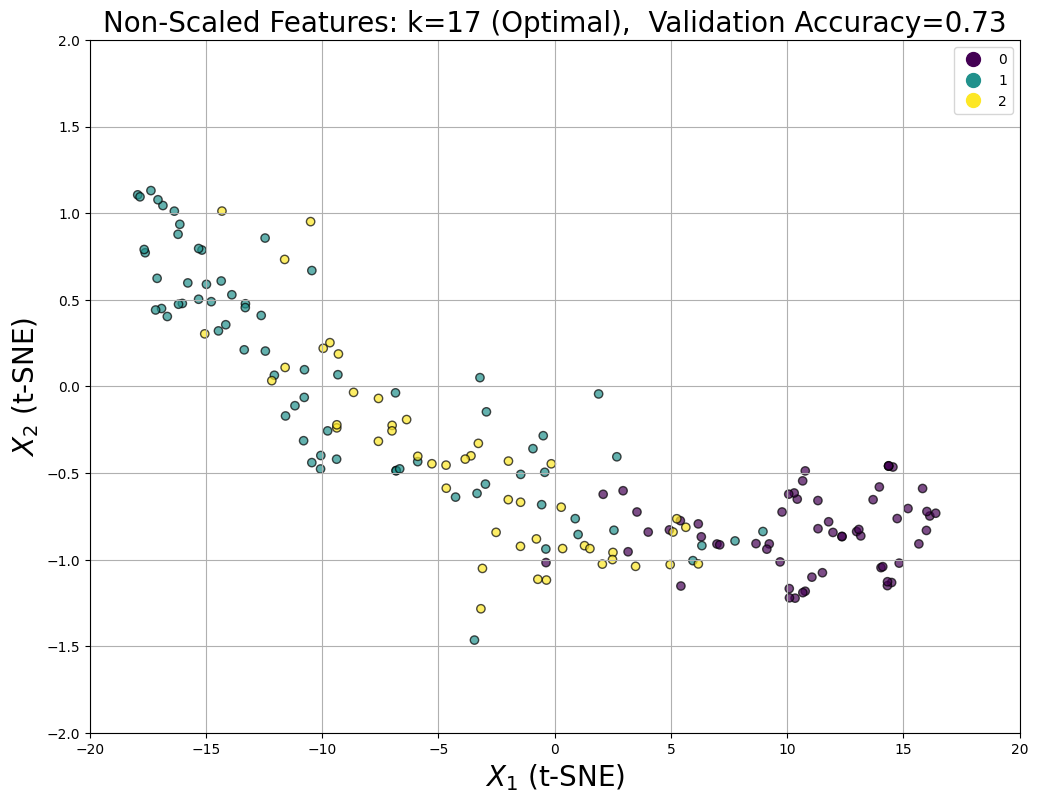

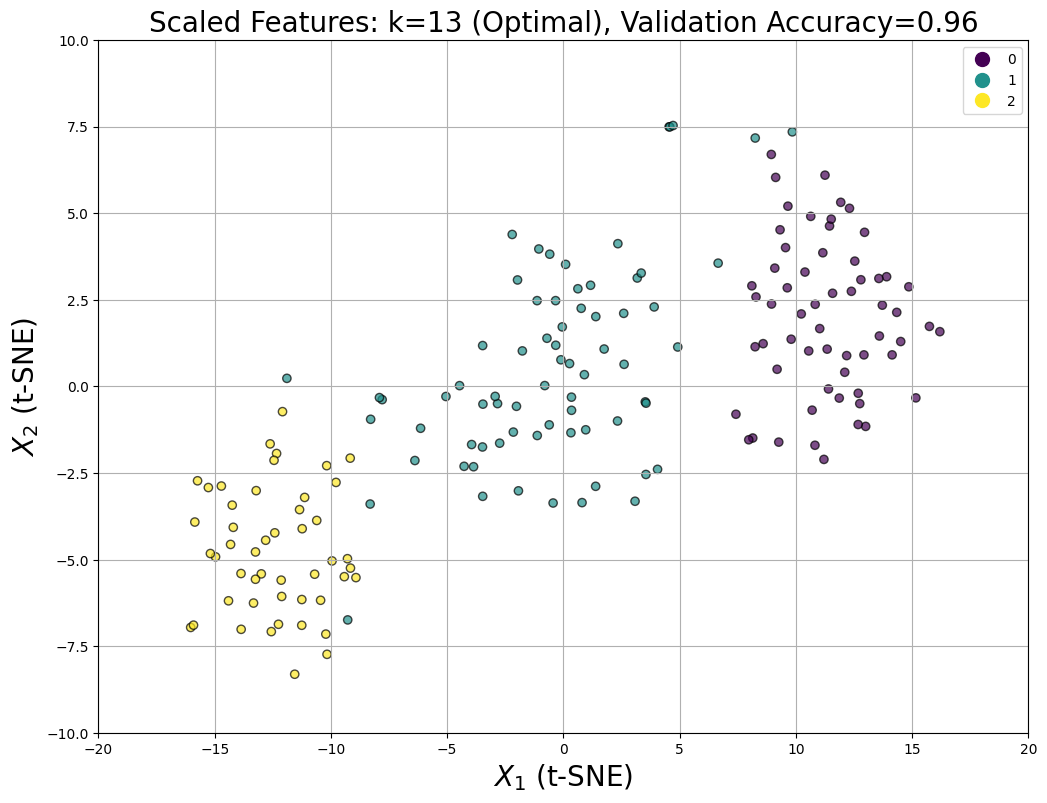

In [ ]:
from sklearn.datasets import load_wine
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Load the Wine dataset
data = load_wine()
X = data.data
y = data.target
target_names = data.target_names

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# t-SNE on the original data
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# t-SNE on the scaled data
tsne_scaled = TSNE(n_components=2, random_state=42)
X_tsne_scaled = tsne_scaled.fit_transform(X_scaled)

# Mapping colors to labels
cmap = plt.cm.viridis
norm = plt.Normalize(y.min(), y.max())

# Figure 1: t-SNE on Original Data
plt.figure(figsize=(12, 9))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap=cmap, edgecolor='k', alpha=0.7, norm=norm)
plt.title('Non-Scaled Features: k=17 (Optimal),  Validation Accuracy=0.73', fontsize=20)
plt.xlabel('$X_1$ (t-SNE)', fontsize=20)
plt.ylabel('$X_2$ (t-SNE)', fontsize=20)
plt.axis([-20, 20, -2, 2])
plt.grid()
# Create a legend:
handles = [plt.Line2D([], [], marker='o', color=cmap(norm(i)), linestyle='', markersize=10, label=name[-1]) for i, name in enumerate(target_names)]
plt.legend(handles=handles)
plt.show()

# Figure 2: t-SNE on Scaled Data
plt.figure(figsize=(12, 9))
scatter = plt.scatter(X_tsne_scaled[:, 0], X_tsne_scaled[:, 1], c=y, cmap=cmap, edgecolor='k', alpha=0.7, norm=norm)
plt.title('Scaled Features: k=13 (Optimal), Validation Accuracy=0.96', fontsize=20)
plt.xlabel('$X_1$ (t-SNE)', fontsize=20)
plt.ylabel('$X_2$ (t-SNE)', fontsize=20)
plt.axis([-20, 20, -10, 10])
plt.grid()
# Create a legend:
handles = [plt.Line2D([], [], marker='o', color=cmap(norm(i)), linestyle='', markersize=10, label=name[-1]) for i, name in enumerate(target_names)]
plt.legend(handles=handles)
plt.show()


In [ ]:
name

NameError: name 'name' is not defined

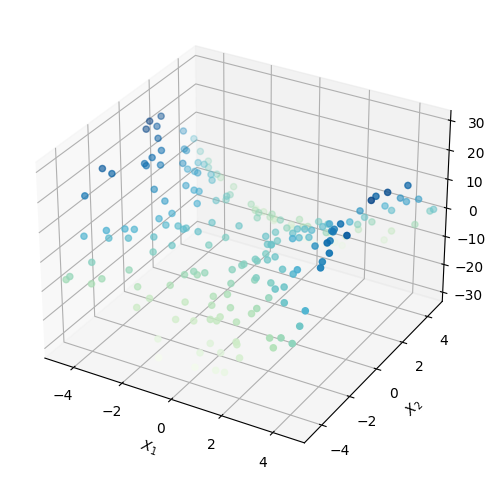

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set the random seed for reproducibility
np.random.seed(0)

# Generate synthetic 2D data for KNN regression
x = np.random.rand(200, 1) * 10 - 5  # X values between -5 and 5
y = np.random.rand(200, 1) * 10 - 5  # Y values between -5 and 5
noise = np.random.normal(0, 1, (200, 1))  # Noise with standard deviation of 1
z = np.power(x, 2) - np.power(y, 2) + noise  # z values as the target variable

# Combine x and y into a single 2D array for the feature set
X = np.hstack((x, y))
y = z.ravel()  # Flatten the z values to a 1D array for the target variable

# Plotting the 3D scatter plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for features X and target y
ax.scatter(X[:, 0], X[:, 1], y, c=y, cmap='GnBu', marker='o')

# Setting labels
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_zlabel('$Y$')
ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])
ax.set_zlim([-32, 32])

# Show plot
plt.show()


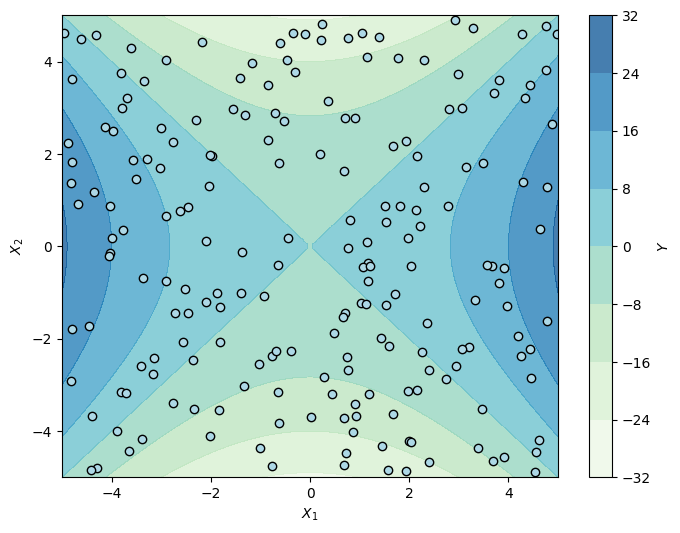

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set the random seed for reproducibility
np.random.seed(0)

# Generate synthetic 2D data for KNN regression
x = np.random.rand(200) * 10 - 5  # X values between -5 and 5
y = np.random.rand(200) * 10 - 5  # Y values between -5 and 5
noise = np.random.normal(0, 1, 200)  # Noise with standard deviation of 1
z = np.power(x, 2) - np.power(y, 2) + noise  # z values as the target variable

# Create a mesh grid for contour plot
xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 100))
zz = np.power(xx, 2) - np.power(yy, 2)

# Plotting
fig = plt.figure(figsize=(8, 6))

# 3D scatter plot with projection
#ax1 = fig.add_subplot(121, projection='3d')
#ax1.scatter(x, y, z, c=z, cmap='viridis', marker='o')
#ax1.plot_surface(xx, yy, zz, cmap='viridis', alpha=0.5)
#ax1.set_xlabel('X-axis')
#ax1.set_ylabel('Y-axis')
#ax1.set_zlabel('Z-axis (Target)')
#ax1.set_title('3D Scatter Plot with Surface Projection')

# 2D contour plot
ax2 = fig.add_subplot(111)
contour = ax2.contourf(xx, yy, zz, cmap='GnBu', alpha=0.75)
#ax2.scatter(x, y, c=z, cmap='Blues', edgecolors='k')  # 2D scatter plot on top of contour
ax2.scatter(x, y, c='lightblue', edgecolors='k')  # 2D scatter plot on top of contour
ax2.set_xlabel('$X_1$')
ax2.set_ylabel('$X_2$')
ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])
cbar = plt.colorbar(contour, ax=ax2)
cbar.set_label('$Y$')

# Show plot
plt.show()


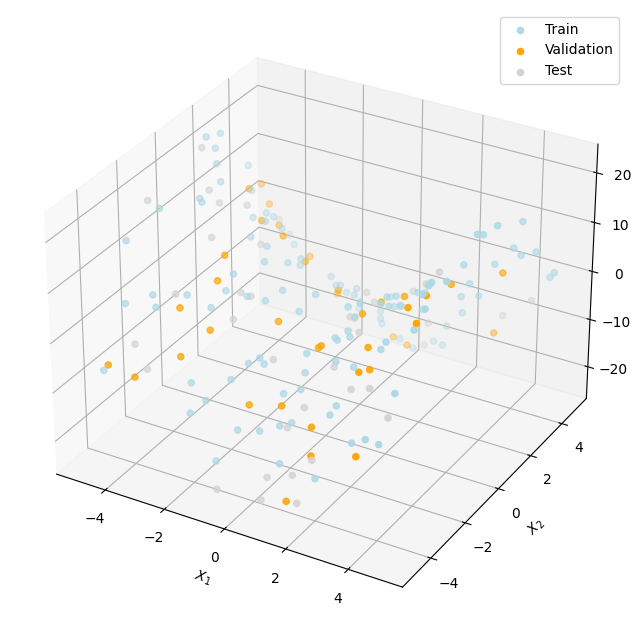

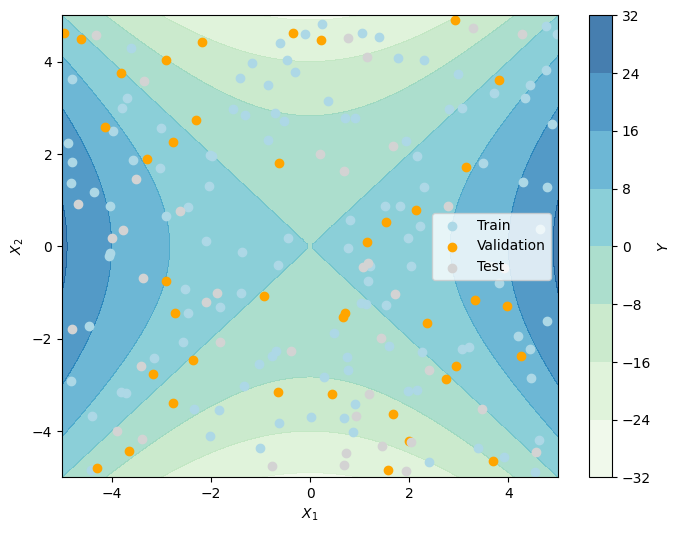

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from mpl_toolkits.mplot3d import Axes3D

# Set the random seed for reproducibility
np.random.seed(0)

# Generate synthetic 2D data for KNN regression
x = np.random.rand(200) * 10 - 5  # X values between -5 and 5
y = np.random.rand(200) * 10 - 5  # Y values between -5 and 5
noise = np.random.normal(0, 1, 200)  # Noise with standard deviation of 1
z = np.power(x, 2) - np.power(y, 2) + noise  # z values as the target variable
data = np.column_stack((x, y, z))

# Splitting data into train, validation, and test sets
train, test = train_test_split(data, test_size=0.2, random_state=0)
train, val = train_test_split(train, test_size=0.25, random_state=0)  # 0.25 * 0.8 = 0.2

# 3D scatter plot with projection
fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.scatter(train[:, 0], train[:, 1], train[:, 2], color='lightblue', label='Train')
ax1.scatter(val[:, 0], val[:, 1], val[:, 2], color='orange', label='Validation')
ax1.scatter(test[:, 0], test[:, 1], test[:, 2], color='lightgray', label='Test')
ax1.set_xlabel('$X_1$')
ax1.set_ylabel('$X_2$')
ax1.set_zlabel('$Y$')
#ax1.set_title('3D Scatter Plot for KNN Regression Data')
ax1.legend()

# 2D contour plot
fig2 = plt.figure(figsize=(8, 6))
ax2 = fig2.add_subplot(111)
contour = ax2.contourf(xx, yy, zz, cmap='GnBu', alpha=0.75)
ax2.scatter(train[:, 0], train[:, 1], color='lightblue', label='Train')
ax2.scatter(val[:, 0], val[:, 1], color='orange', label='Validation')
ax2.scatter(test[:, 0], test[:, 1], color='lightgray', label='Test')
ax2.set_xlabel('$X_1$')
ax2.set_ylabel('$X_2$')
#ax2.set_title('2D Contour Plot with Scatter Overlay')
ax2.legend()
cbar = plt.colorbar(contour, ax=ax2)
cbar.set_label('$Y$')

plt.show()


In [36]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# KNN Regressor initialization with k=5
k = 5
knn_regressor = KNeighborsRegressor(n_neighbors=k)

# Extracting features and target variables for training and validation sets
X_train = train[:, :2]
y_train = train[:, 2]
X_val = val[:, :2]
y_val = val[:, 2]

# Training the KNN regressor on the training data
knn_regressor.fit(X_train, y_train)

# Predicting on the validation data
y_val_pred = knn_regressor.predict(X_val)

# Calculating the mean squared error for the validation predictions
mse_val = mean_squared_error(y_val, y_val_pred)

print("Mean Squared Error on the Validation Dataset:", mse_val)


Mean Squared Error on the Validation Dataset: 9.696288484322912


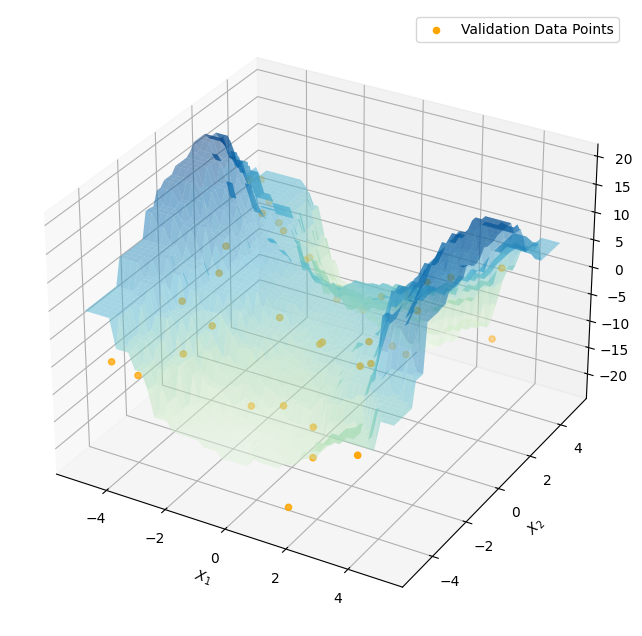

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import KNeighborsRegressor

# Assume 'knn_regressor' is already trained and 'X_val', 'y_val' are defined from previous steps
# Creating a mesh grid for the surface plot based on the feature space
xx, yy = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-5, 5, 50))

# Predicting on the mesh grid to generate the surface plot
Z_predict = knn_regressor.predict(np.c_[xx.ravel(), yy.ravel()])
Z_predict = Z_predict.reshape(xx.shape)

# Plotting the surface plot and overlaying the validation data points
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(xx, yy, Z_predict, cmap='GnBu', alpha=0.5)
scatter = ax.scatter(X_val[:, 0], X_val[:, 1], y_val, color='orange', label='Validation Data Points')

# Adding labels and title
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_zlabel('$Y$')
ax.legend()

# Show plot
plt.show()


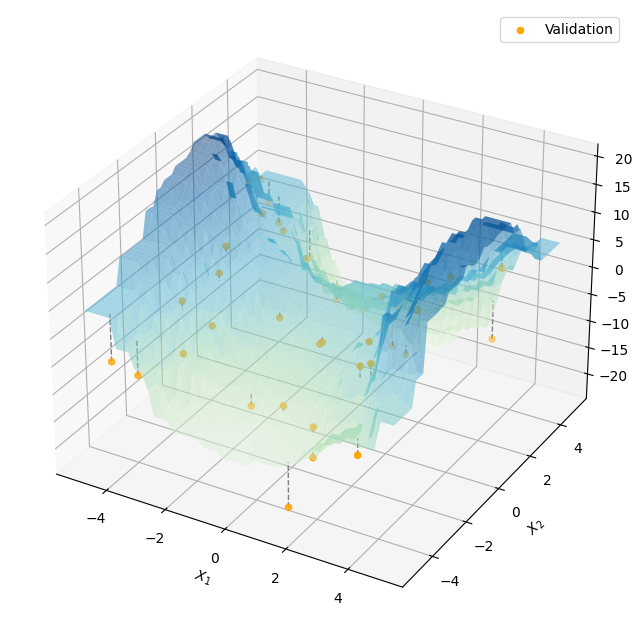

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import KNeighborsRegressor

# Assume 'knn_regressor' is already trained and 'X_val', 'y_val' are defined from previous steps
# Creating a mesh grid for the surface plot based on the feature space
xx, yy = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-5, 5, 50))

# Predicting on the mesh grid to generate the surface plot
Z_predict = knn_regressor.predict(np.c_[xx.ravel(), yy.ravel()])
Z_predict = Z_predict.reshape(xx.shape)

# Predicting the z values for the validation data points to project them onto the surface
z_val_pred = knn_regressor.predict(X_val)

# Plotting the surface plot and overlaying the validation data points
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(xx, yy, Z_predict, cmap='GnBu', alpha=0.5)
scatter = ax.scatter(X_val[:, 0], X_val[:, 1], y_val, color='orange', label='Validation')

# Adding dashed lines between actual data points and their predicted positions on the surface
for i in range(len(X_val)):
    ax.plot([X_val[i, 0], X_val[i, 0]], [X_val[i, 1], X_val[i, 1]], [y_val[i], z_val_pred[i]], 'gray', linestyle='dashed', linewidth=1)

# Adding labels and title
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_zlabel('$Y$')
ax.legend()

# Show plot
plt.show()


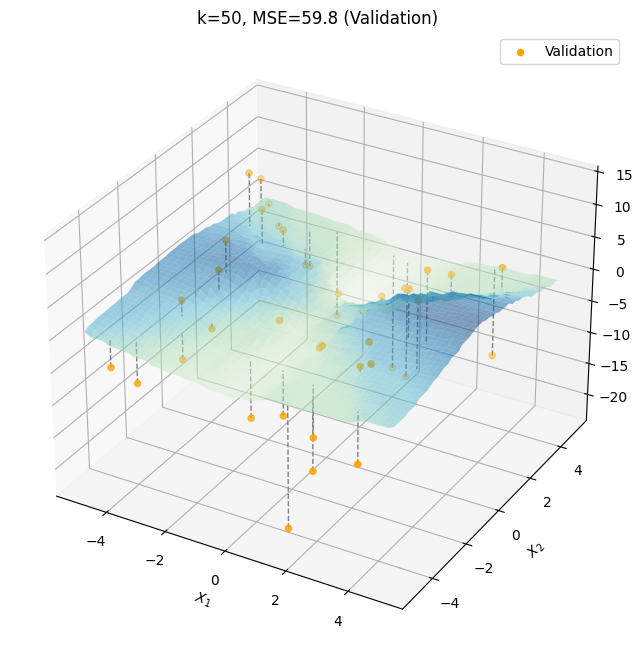

In [56]:
# KNN Regressor initialization with k=5
k = 50

knn_regressor = KNeighborsRegressor(n_neighbors=k)

# Extracting features and target variables for training and validation sets
X_train = train[:, :2]
y_train = train[:, 2]
X_val = val[:, :2]
y_val = val[:, 2]

# Training the KNN regressor on the training data
knn_regressor.fit(X_train, y_train)

# Predicting on the validation data
y_val_pred = knn_regressor.predict(X_val)

# Calculating the mean squared error for the validation predictions
mse_val = mean_squared_error(y_val, y_val_pred)

# Assume 'knn_regressor' is already trained and 'X_val', 'y_val' are defined from previous steps
# Creating a mesh grid for the surface plot based on the feature space
xx, yy = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-5, 5, 50))

# Predicting on the mesh grid to generate the surface plot
Z_predict = knn_regressor.predict(np.c_[xx.ravel(), yy.ravel()])
Z_predict = Z_predict.reshape(xx.shape)

# Predicting the z values for the validation data points to project them onto the surface
z_val_pred = knn_regressor.predict(X_val)

# Plotting the surface plot and overlaying the validation data points
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
surface = ax.plot_surface(xx, yy, Z_predict, cmap='GnBu', alpha=0.5)
scatter = ax.scatter(X_val[:, 0], X_val[:, 1], y_val, color='orange', label='Validation')

# Adding dashed lines between actual data points and their predicted positions on the surface
for i in range(len(X_val)):
    ax.plot([X_val[i, 0], X_val[i, 0]], [X_val[i, 1], X_val[i, 1]], [y_val[i], z_val_pred[i]], 'gray', linestyle='dashed', linewidth=1)

# Adding labels and title
ax.set_xlabel('$X_1$')
ax.set_ylabel('$X_2$')
ax.set_zlabel('$Y$')
ax.legend()
ax.set_title("k=" + str(k) + ", MSE=" + str(round(mse_val,2)) + " (Validation)")

# Show plot
plt.show()


In [58]:
neighbours = np.arange(1,31)
validation_scores = []
train_scores = []
for k in neighbours :
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_val)

    validation_scores.append(mean_squared_error(y_val, knn.predict(X_val)))
    train_scores.append(mean_squared_error(y_train, knn.predict(X_train)))

validation_scores = np.array(validation_scores)
train_scores = np.array(train_scores)

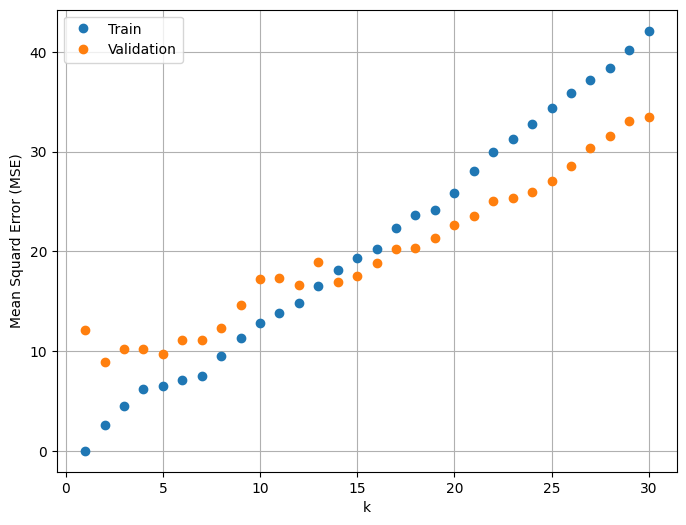

In [60]:
plt.figure(figsize=(8, 6))
plt.plot(neighbours, train_scores, 'o', label="Train")
plt.plot(neighbours, validation_scores, 'o', label="Validation")
plt.xlabel('k')
plt.ylabel('Mean Squard Error (MSE)')
#plt.axis([0, 30, 0.0, 1.0])
plt.grid()
plt.legend()
plt.show()

In [61]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Load the diabetes dataset
diabetes = datasets.load_diabetes()
X = diabetes.data
y = diabetes.target

# Applying one-hot encoding to the 'sex' variable
# Note: 'sex' is the second column in the dataset
encoder = OneHotEncoder(sparse=False)
sex_encoded = encoder.fit_transform(X[:, 1:2])  # Reshape to 2D array for encoder

# Replace the 'sex' column in X with the encoded columns
X = np.delete(X, 1, axis=1)  # Remove the original 'sex' column
X = np.hstack((X, sex_encoded))  # Concatenate the one-hot encoded columns to the features

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Print shapes of the training and testing datasets
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (353, 11)
Testing set shape: (89, 11)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


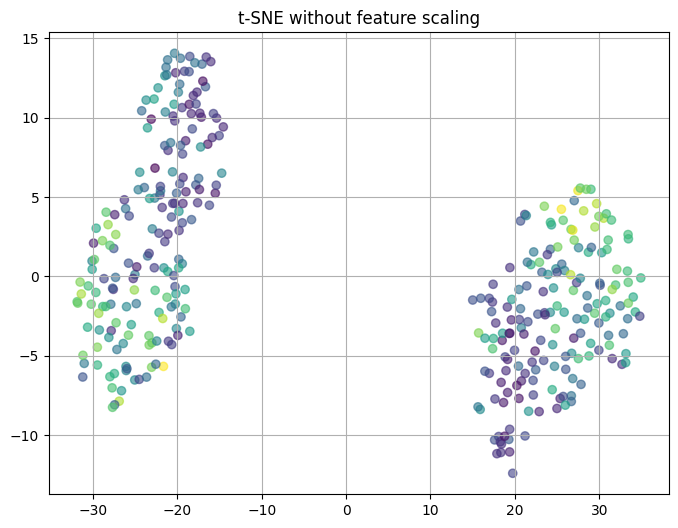

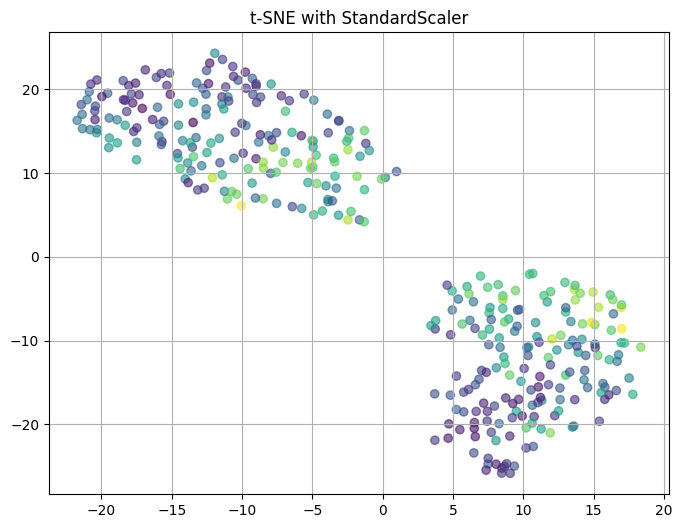

In [67]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Assuming X_train and y_train are already defined

# Create the t-SNE transformation of the training dataset
tsne = TSNE(n_components=2, random_state=0)
X_train_tsne = tsne.fit_transform(X_train)

# Apply StandardScaler to the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled_tsne = tsne.fit_transform(X_train_scaled)

# Plotting the t-SNE transformation without scaling
plt.figure(figsize=(8, 6))  # Creates a new figure
plt.scatter(X_train_tsne[:, 0], X_train_tsne[:, 1], c=y_train, cmap='viridis', alpha=0.6)
#plt.colorbar()
plt.grid()
plt.title('t-SNE without feature scaling')
plt.show()  # Display the plot

# Plotting the t-SNE transformation with scaling
plt.figure(figsize=(8, 6))  # Creates another new figure
plt.scatter(X_train_scaled_tsne[:, 0], X_train_scaled_tsne[:, 1], c=y_train, cmap='viridis', alpha=0.6)
#plt.colorbar()
plt.grid()
plt.title('t-SNE with StandardScaler')
plt.show()  # Display the plot


In [63]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# Assuming X_train and y_train are already defined

# Range of k to test from 1 to 30
k_values = range(1, 31)

# List to store mean MSE for each k
mean_mse = []

for k in k_values:
    # Initialize KNN Regressor with k neighbors
    knn_regressor = KNeighborsRegressor(n_neighbors=k)

    # Compute cross-validation scores (neg_mean_squared_error returns negative values)
    scores = cross_val_score(knn_regressor, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

    # Calculate mean of the cross-validation MSE scores and convert to positive
    mean_mse.append(-scores.mean())

# Best MSE and corresponding k (minimum MSE)
best_k = k_values[np.argmin(mean_mse)]
best_mse = min(mean_mse)

print("Best k:", best_k)
print("Best cross-validation MSE:", best_mse)


Best k: 15
Best cross-validation MSE: 3177.353519159401


In [64]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# Assuming X_train and y_train are already defined

# Apply StandardScaler to the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Range of k to test from 1 to 30
k_values = range(1, 31)

# List to store mean MSE for each k
mean_mse_scaled = []

for k in k_values:
    # Initialize KNN Regressor with k neighbors
    knn_regressor = KNeighborsRegressor(n_neighbors=k)

    # Compute cross-validation scores (neg_mean_squared_error returns negative values)
    scores = cross_val_score(knn_regressor, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')

    # Calculate mean of the cross-validation MSE scores and convert to positive
    mean_mse_scaled.append(-scores.mean())

# Best MSE and corresponding k (minimum MSE) for scaled features
best_k_scaled = k_values[np.argmin(mean_mse_scaled)]
best_mse_scaled = min(mean_mse_scaled)

print("Best k for scaled features:", best_k_scaled)
print("Best cross-validation MSE for scaled features:", best_mse_scaled)


Best k for scaled features: 13
Best cross-validation MSE for scaled features: 3138.8107785172574


In [65]:
from sklearn.metrics import mean_squared_error

# Assuming best_k and best_k_scaled have been determined from previous steps
# Assuming X_train, y_train, X_test, and y_test are already defined

# Train KNN regressor with best k for non-scaled features
knn_regressor_non_scaled = KNeighborsRegressor(n_neighbors=best_k)
knn_regressor_non_scaled.fit(X_train, y_train)
y_test_pred_non_scaled = knn_regressor_non_scaled.predict(X_test)
mse_test_non_scaled = mean_squared_error(y_test, y_test_pred_non_scaled)

# Train KNN regressor with best k for scaled features
knn_regressor_scaled = KNeighborsRegressor(n_neighbors=best_k_scaled)
knn_regressor_scaled.fit(X_train_scaled, y_train)  # Note: Model must be trained on scaled data
X_test_scaled = scaler.transform(X_test)  # Scale the test data using the same scaler as training data
y_test_pred_scaled = knn_regressor_scaled.predict(X_test_scaled)
mse_test_scaled = mean_squared_error(y_test, y_test_pred_scaled)

print("MSE on test dataset (non-scaled features):", mse_test_non_scaled)
print("MSE on test dataset (scaled features):", mse_test_scaled)


MSE on test dataset (non-scaled features): 3353.407890137328
MSE on test dataset (scaled features): 3548.4786250914167


In [69]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np

# Load the California housing dataset
california = fetch_california_housing()
X = california.data
y = california.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# StandardScaler for feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Range of k to test from 1 to 30
k_values = range(1, 31)

# Function to find best k using cross-validation
def find_best_k(X, y):
    mean_mse = []
    for k in k_values:
        knn = KNeighborsRegressor(n_neighbors=k)
        scores = cross_val_score(knn, X, y, cv=5, scoring='neg_mean_squared_error')
        mean_mse.append(-scores.mean())
    best_k = k_values[np.argmin(mean_mse)]
    best_mse = min(mean_mse)
    return best_k, best_mse

# Find best k for non-scaled features
best_k_non_scaled, best_mse_non_scaled = find_best_k(X_train, y_train)
print("Best k (non-scaled):", best_k_non_scaled)
print("Best cross-validation MSE (non-scaled):", best_mse_non_scaled)

# Find best k for scaled features
best_k_scaled, best_mse_scaled = find_best_k(X_train_scaled, y_train)
print("Best k (scaled):", best_k_scaled)
print("Best cross-validation MSE (scaled):", best_mse_scaled)

# Train and evaluate the models with the best k
knn_non_scaled = KNeighborsRegressor(n_neighbors=best_k_non_scaled)
knn_non_scaled.fit(X_train, y_train)
y_pred_non_scaled = knn_non_scaled.predict(X_test)
mse_non_scaled = mean_squared_error(y_test, y_pred_non_scaled)
print("Test MSE (non-scaled):", mse_non_scaled)

knn_scaled = KNeighborsRegressor(n_neighbors=best_k_scaled)
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
print("Test MSE (scaled):", mse_scaled)


Best k (non-scaled): 8
Best cross-validation MSE (non-scaled): 1.1432959472352686
Best k (scaled): 10
Best cross-validation MSE (scaled): 0.39350101161607903
Test MSE (non-scaled): 1.0892545840494126
Test MSE (scaled): 0.3909628171015683


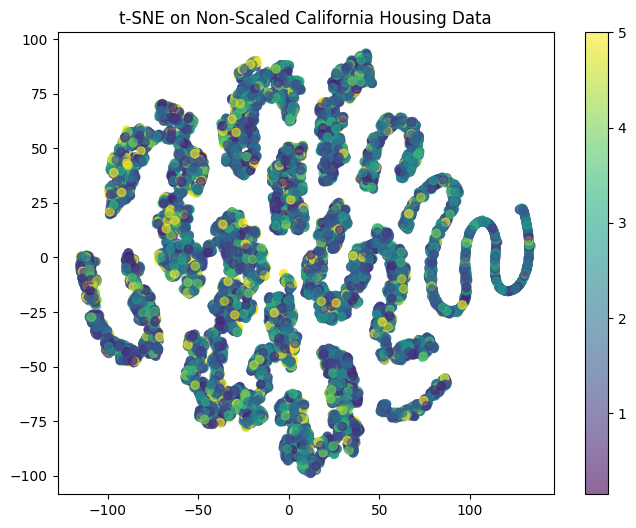

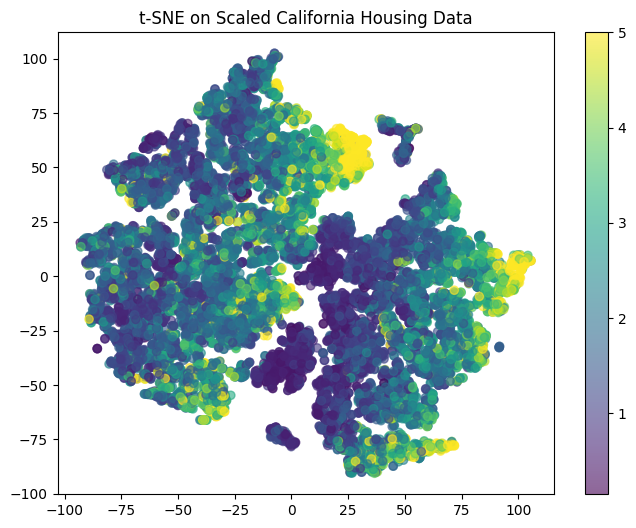

In [70]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the California housing dataset
california = fetch_california_housing()
X = california.data
y = california.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# StandardScaler for feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Create the t-SNE transformation of the non-scaled training dataset
tsne_non_scaled = TSNE(n_components=2, random_state=0)
X_train_tsne_non_scaled = tsne_non_scaled.fit_transform(X_train)

# Create the t-SNE transformation of the scaled training dataset
tsne_scaled = TSNE(n_components=2, random_state=0)
X_train_tsne_scaled = tsne_scaled.fit_transform(X_train_scaled)

# Plotting the t-SNE transformation for non-scaled features
plt.figure(figsize=(8, 6))
plt.scatter(X_train_tsne_non_scaled[:, 0], X_train_tsne_non_scaled[:, 1], c=y_train, cmap='viridis', alpha=0.6)
plt.colorbar()
plt.title('t-SNE on Non-Scaled California Housing Data')
plt.show()

# Plotting the t-SNE transformation for scaled features
plt.figure(figsize=(8, 6))
plt.scatter(X_train_tsne_scaled[:, 0], X_train_tsne_scaled[:, 1], c=y_train, cmap='viridis', alpha=0.6)
plt.colorbar()
plt.title('t-SNE on Scaled California Housing Data')
plt.show()
